# 2. Análisis exploratorio de datos

Todo el EDA se hace **solo con el conjunto de entrenamiento**. En este entregable (un solo sitio) es la serie de la finca entre 1981 y 2020; con la grilla regional (segundo entregable) serán los sitios regionales hasta 2020, con la finca reservada como sitio no visto. El periodo 2021–2025 se reservó en el capítulo anterior y no se mira hasta la evaluación final. Las figuras de una sola serie usan el sitio de referencia `REF`.

El objetivo de pronóstico es la lluvia acumulada semanal. Por eso muchos análisis se hacen en escala semanal además de la diaria.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
np.random.seed(cfg.SEED)
plt.rcParams["figure.dpi"] = 110
import seaborn as sns
from scipy import stats
from src import modelado as md, espacial as esp

In [2]:
df = pd.read_csv(cfg.DATA_PROCESSED / cfg.ARCHIVO_DATOS, parse_dates=["fecha"])
OBJ = "PRECTOTCORR"
N_SITIOS = df["punto"].nunique()
if N_SITIOS == 1:
    # Plan B (un solo sitio): el entrenamiento es 1981-2020 del mismo sitio; 2021-2025 es prueba
    train_df = df[df["fecha"] < cfg.INICIO_TEST].copy()
    REF = df["punto"].iloc[0]
else:
    # Diseño regional: sitios regionales antes de 2021; la finca y 2021-2025 quedan fuera del EDA
    train_df = df[(df["fecha"] < cfg.INICIO_TEST) & (df["punto"] != cfg.PUNTO_OBJETIVO)].copy()
    _c = train_df.groupby("punto")[["lat", "lon"]].first()
    REF = ((_c.lat - cfg.LAT_FINCA) ** 2 + (_c.lon - cfg.LON_FINCA) ** 2).idxmin()
print(train_df.shape, train_df["fecha"].min().date(), "→", train_df["fecha"].max().date(),
      "| sitios:", train_df.punto.nunique(), "| referencia:", REF)
VARS = [c for c in cfg.POWER_PARAMS if c in train_df] + [c for c in ["ONI"] if c in train_df]   # solo variables del Excel / NASA POWER
semanal = md.semanal_por_punto(train_df, VARS)   # semanas completas lunes-domingo
obj_sem = semanal[semanal.punto == REF].set_index("fecha")
print(semanal.shape)

(14610, 16) 1981-01-01 → 2020-12-31 | sitios: 1 | referencia: FINCA_SABANAGRANDE
(2086, 12)


## 2.1 Variable objetivo

In [3]:
P = train_df[OBJ]
Pw = semanal[OBJ]
resumen = pd.DataFrame({
    "diaria": [P.mean(), P.median(), P.std(), (P < 1).mean(), stats.skew(P), stats.kurtosis(P), P.quantile(.95), P.max()],
    "semanal": [Pw.mean(), Pw.median(), Pw.std(), (Pw < 1).mean(), stats.skew(Pw), stats.kurtosis(Pw), Pw.quantile(.95), Pw.max()],
}, index=["media", "mediana", "desv. est.", "proporción < 1 mm", "asimetría", "curtosis", "p95", "máximo"])
resumen.round(3)

,diaria,semanal
media,2.638,18.46
mediana,0.47,7.015
desv. est.,5.433,27.24
proporción < 1 mm,0.579,0.316
asimetría,5.852,2.971
curtosis,66.02,16.98
p95,11.99,72.19
máximo,108,354.6


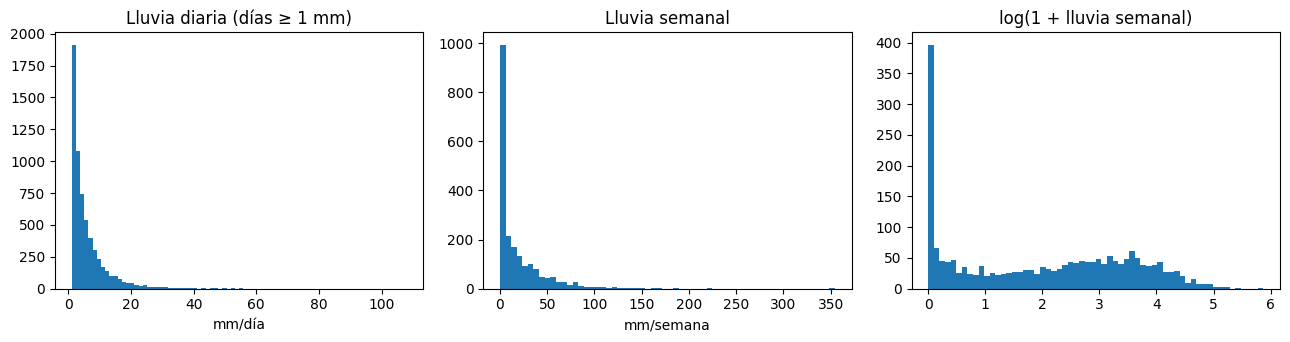

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].hist(P[P >= 1], bins=80); ax[0].set_title("Lluvia diaria (días ≥ 1 mm)"); ax[0].set_xlabel("mm/día")
ax[1].hist(Pw, bins=60); ax[1].set_title("Lluvia semanal"); ax[1].set_xlabel("mm/semana")
ax[2].hist(np.log1p(Pw), bins=60); ax[2].set_title("log(1 + lluvia semanal)")
plt.tight_layout(); plt.show()

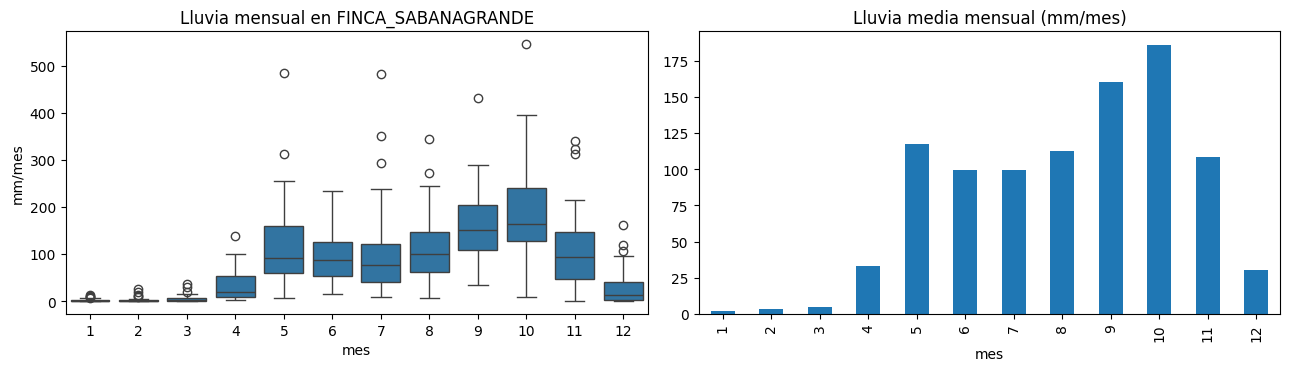

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
mens = train_df.assign(mes=train_df.fecha.dt.month, anio=train_df.fecha.dt.year)
mens = mens.groupby(["punto", "anio", "mes"])[OBJ].sum().reset_index()
sns.boxplot(data=mens[mens.punto == REF], x="mes", y=OBJ, ax=ax[0])
ax[0].set_title(f"Lluvia mensual en {REF}"); ax[0].set_ylabel("mm/mes")
if N_SITIOS > 1:
    sns.lineplot(data=mens, x="mes", y=OBJ, hue="punto", estimator="mean", errorbar=None, ax=ax[1]); ax[1].set_title("Climatología mensual por punto")
else:
    clim_m = train_df.groupby(train_df.fecha.dt.month)[OBJ].mean() * 30.4
    clim_m.plot.bar(ax=ax[1]); ax[1].set_title("Lluvia media mensual (mm/mes)"); ax[1].set_xlabel("mes")
plt.tight_layout(); plt.show()

**Interpretación.** La lluvia semanal tiene una media de 18,5 mm y una mediana de 7,0 mm, asimetría de 2,97 y curtosis de 17: pocas semanas muy lluviosas concentran buena parte del total. El 9,9 % de las semanas no tiene lluvia y el 31,6 % tiene menos de 1 mm. La transformación log(1+y) reduce la asimetría a 0,07. El ciclo anual es bimodal: enero–marzo casi sin lluvia (2 a 5 mm/mes), un primer pico en mayo (118 mm), una leve disminución en junio–julio (veranillo, unos 99 mm) y el máximo en octubre (186 mm). **Implicaciones:** (1) MAPE es inestable con semanas de lluvia nula o casi nula, así que se prioriza WAPE y MAE; (2) la validación debe ser cronológica por la fuerte estacionalidad; (3) la climatología por semana del año es una línea base exigente; (4) la transformación del objetivo se trata como hiperparámetro en el modelo base.

## 2.2 Análisis unidimensional

In [6]:
desc = train_df[VARS].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc["asimetría"] = train_df[VARS].skew()
desc["curtosis"] = train_df[VARS].kurt()
q1, q3 = train_df[VARS].quantile(.25), train_df[VARS].quantile(.75)
iqr = q3 - q1
desc["outliers_IQR_%"] = (((train_df[VARS] < q1 - 1.5 * iqr) | (train_df[VARS] > q3 + 1.5 * iqr)).mean() * 100)
desc.round(3)

,count,mean,std,min,5%,25%,50%,75%,95%,max,asimetría,curtosis,outliers_IQR_%
PRECTOTCORR,1.461e+04,2.638,5.433,0,0,0.01,0.47,2.968,11.99,108,5.853,66.05,10.63
T2M,1.461e+04,27.67,0.809,24.52,26.29,27.11,27.7,28.23,28.95,30.31,-0.149,-0.22,0.246
T2M_MAX,1.461e+04,30.41,1.216,25.39,28.37,29.61,30.41,31.22,32.37,34.75,-0.098,0.032,0.842
T2M_MIN,1.461e+04,25.96,0.901,22.43,24.34,25.38,26.07,26.62,27.28,28.66,-0.457,-0.137,0.575
RH2M,1.461e+04,79.88,4.936,63.69,71.31,76.3,80.34,83.69,87.22,92.55,-0.266,-0.571,0.089
WS2M,1.461e+04,4.154,1.349,0.75,1.83,3.17,4.22,5.17,6.26,8.15,-0.116,-0.684,0
ALLSKY_SFC_SW_DWN,1.352e+04,19.37,3.428,2.56,13.01,17.45,19.83,21.8,24.11,26.77,-0.824,0.957,1.93
PS,1.461e+04,100.5,0.128,100.1,100.3,100.5,100.5,100.6,100.8,101,0.057,0.153,0.931
GWETROOT,1.461e+04,0.712,0.119,0.58,0.59,0.6,0.68,0.8,0.94,1,0.689,-0.717,0
GWETTOP,1.461e+04,0.629,0.219,0.19,0.24,0.47,0.66,0.8,0.93,0.99,-0.457,-0.92,0


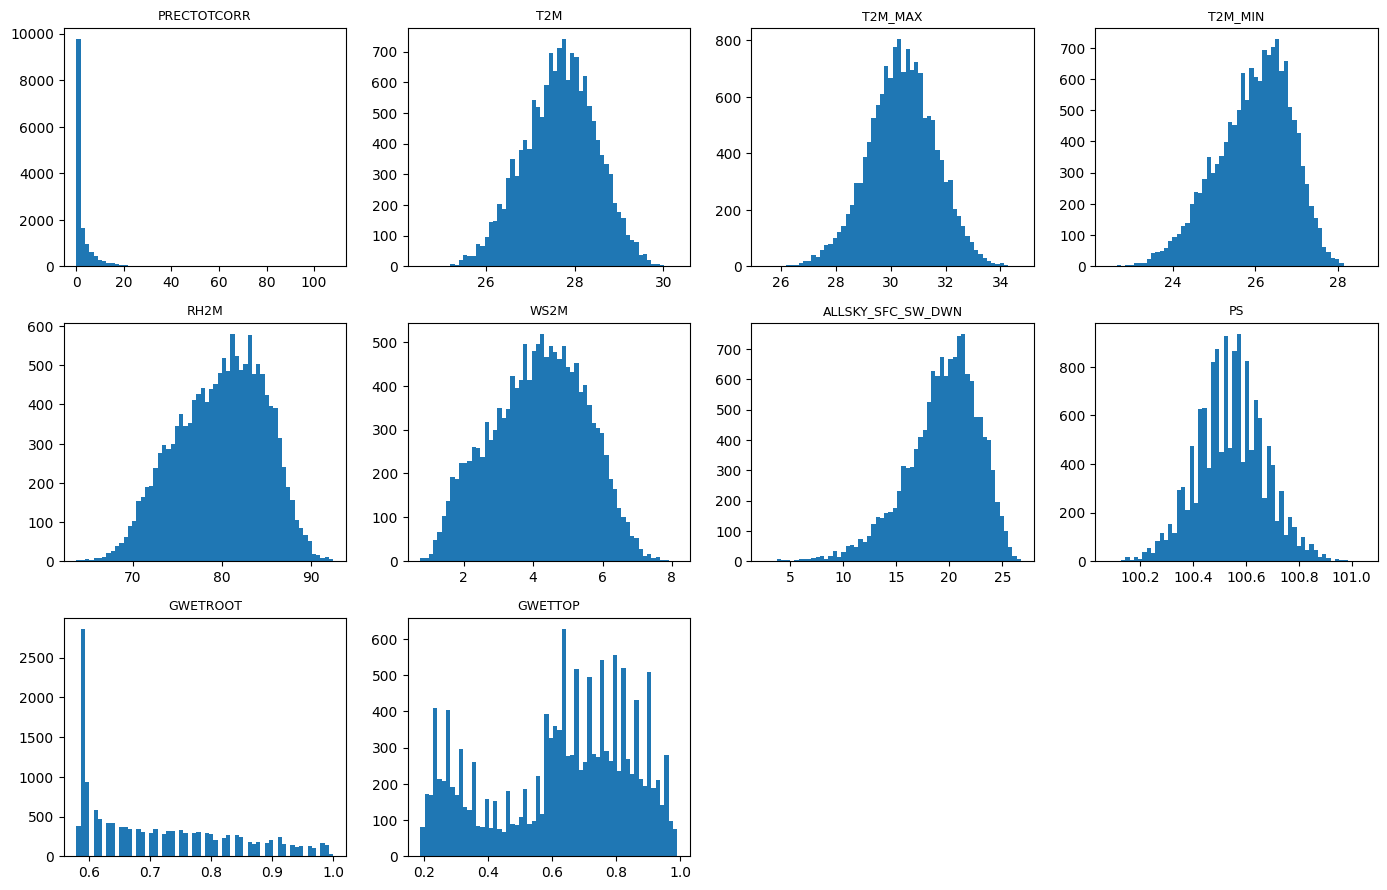

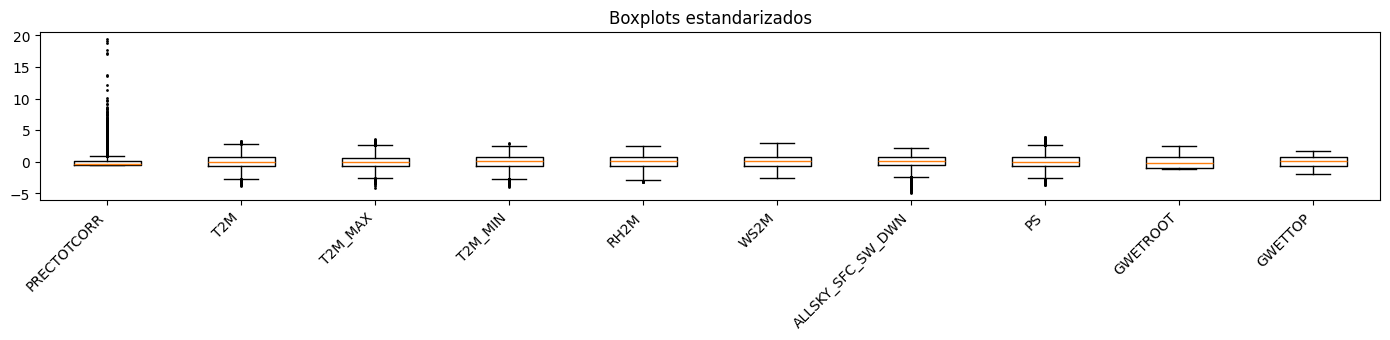

In [7]:
n = len(VARS); cols = 4; filas = int(np.ceil(n / cols))
fig, axs = plt.subplots(filas, cols, figsize=(14, 3 * filas))
for a, v in zip(axs.ravel(), VARS):
    a.hist(train_df[v].dropna(), bins=60); a.set_title(v, fontsize=9)
for a in axs.ravel()[n:]:
    a.axis("off")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(14, 3.5))
z = (train_df[VARS] - train_df[VARS].mean()) / train_df[VARS].std()
ax.boxplot([z[v].dropna() for v in VARS], tick_labels=VARS, showfliers=True, flierprops={"markersize": 1})
ax.set_title("Boxplots estandarizados"); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

**Normalidad.** Con decenas de miles de datos las pruebas de normalidad rechazan casi siempre, por eso se aplican a una muestra de 500 semanas y se interpretan junto con la asimetría y la curtosis, no por sí solas.

In [8]:
muestra = semanal.sample(min(500, len(semanal)), random_state=cfg.SEED)
pd.DataFrame({v: stats.normaltest(muestra[v].dropna()) for v in VARS}, index=["estadístico", "p"]).T.round(4)

,estadístico,p
PRECTOTCORR,289.8,0
T2M,2.828,0.2431
T2M_MAX,1.103,0.576
T2M_MIN,20.78,0
RH2M,52.89,0
WS2M,34.5,0
ALLSKY_SFC_SW_DWN,5.224,0.0734
PS,1.335,0.5131
GWETROOT,54.91,0
GWETTOP,123.8,0


### Variables categóricas derivadas

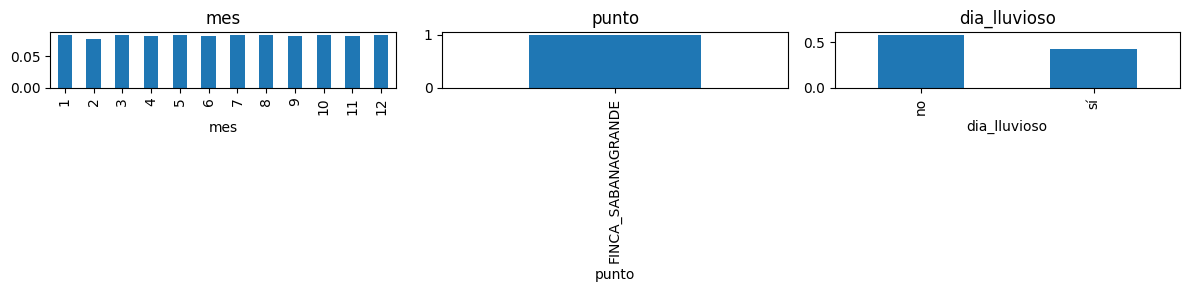

In [9]:
cat = pd.DataFrame({
    "mes": train_df.fecha.dt.month,
    "punto": train_df.punto,
    "dia_lluvioso": np.where(train_df[OBJ] >= 1, "sí", "no"),
})
if "ONI" in train_df:
    cat["fase_enso"] = pd.cut(train_df["ONI"], [-np.inf, -0.5, 0.5, np.inf], labels=["La Niña", "Neutral", "El Niño"])
fig, axs = plt.subplots(1, cat.shape[1], figsize=(4 * cat.shape[1], 3))
for a, c in zip(np.atleast_1d(axs), cat.columns):
    cat[c].value_counts(normalize=True).sort_index().plot.bar(ax=a); a.set_title(c)
plt.tight_layout(); plt.show()

In [10]:
prop = (train_df[OBJ] >= 1).groupby(train_df.fecha.dt.month).mean()
print("Proporción de días con lluvia >= 1 mm por mes:")
prop.round(2).rename("proporción").to_frame().T

Proporción de días con lluvia >= 1 mm por mes:


fecha,1,2,3,4,5,6,7,8,9,10,11,12
proporción,0.02,0.02,0.04,0.23,0.58,0.62,0.51,0.66,0.82,0.82,0.53,0.16


**Interpretación.** La precipitación es la única variable con asimetría (5,85) y curtosis (66) extremas; la regla IQR marca el 10,6 % de los días como atípicos, pero son lluvias reales y se conservan. Las temperaturas y la presión son casi simétricas: sobre una muestra de 500 semanas no se rechaza la normalidad de T2M, T2M_MAX ni PS; sí se rechaza para la lluvia, la humedad relativa y la humedad del suelo. La humedad del suelo superficial (GWETTOP) es bimodal, reflejo de los regímenes seco y húmedo. El viento medio de 4,2 m/s es alto por la cercanía a la costa. La proporción de días con lluvia ≥ 1 mm va de 2 % en enero–febrero a 82 % en septiembre–octubre: la estacionalidad es el factor dominante.

## 2.3 Análisis bidimensional

Para que el análisis sirva al pronóstico, las predictoras se relacionan con la lluvia **de la semana siguiente** (horizonte h = 1), usando solo información pasada.

In [11]:
tab1 = md.tabla_modelado(train_df, h=1)
tab1 = tab1[tab1.fecha < cfg.INICIO_TEST]
pred_cols = md.columnas_predictoras(tab1)
print(len(tab1), "filas;", len(pred_cols), "predictoras")

2086 filas; 26 predictoras


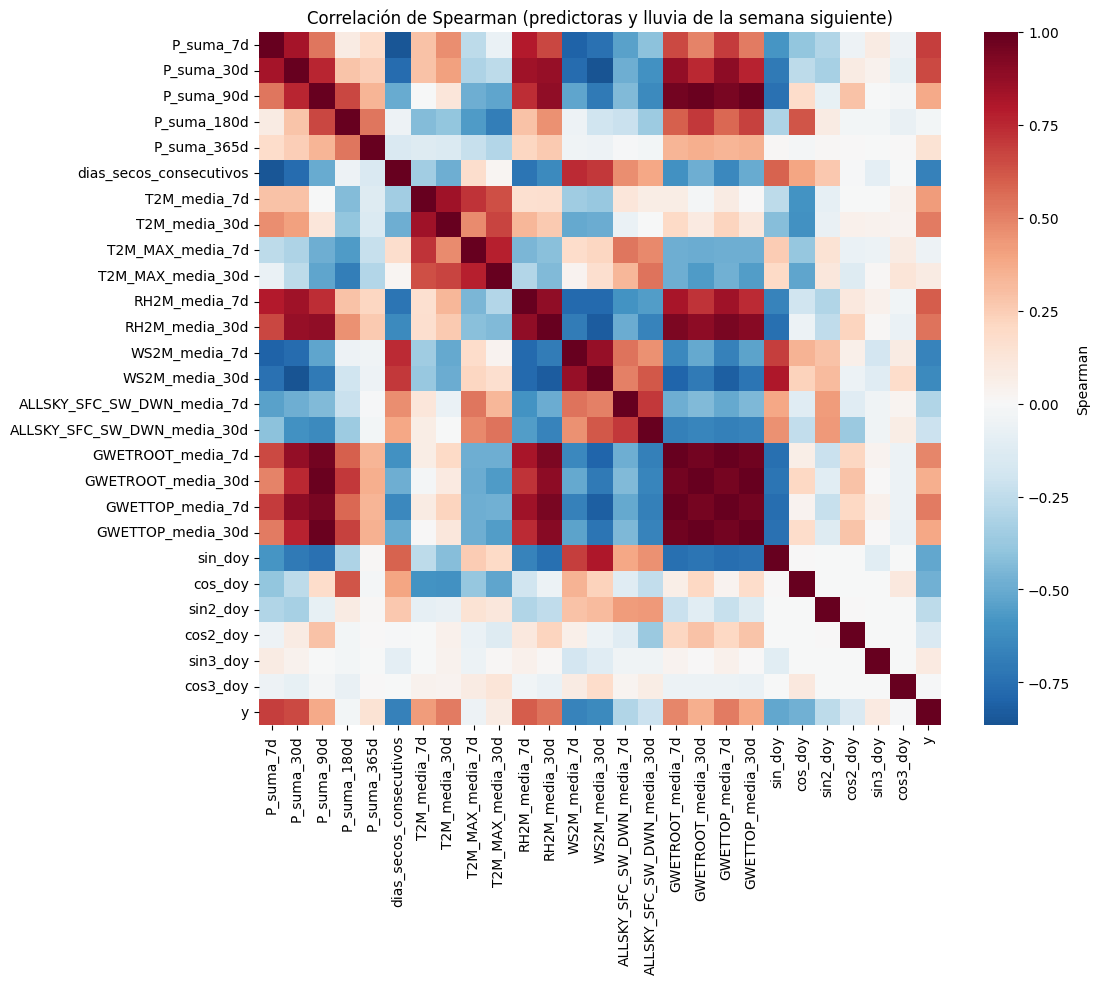

,y
P_suma_7d,0.693
dias_secos_consecutivos,-0.67
WS2M_media_7d,-0.664
P_suma_30d,0.661
WS2M_media_30d,-0.638
RH2M_media_7d,0.607
RH2M_media_30d,0.535
T2M_media_30d,0.518
sin_doy,-0.518
GWETTOP_media_7d,0.513


In [12]:
corr = tab1[pred_cols + ["y"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Spearman"})
ax.set_title("Correlación de Spearman (predictoras y lluvia de la semana siguiente)"); plt.show()
corr["y"].drop("y").sort_values(key=np.abs, ascending=False).round(3).head(15)

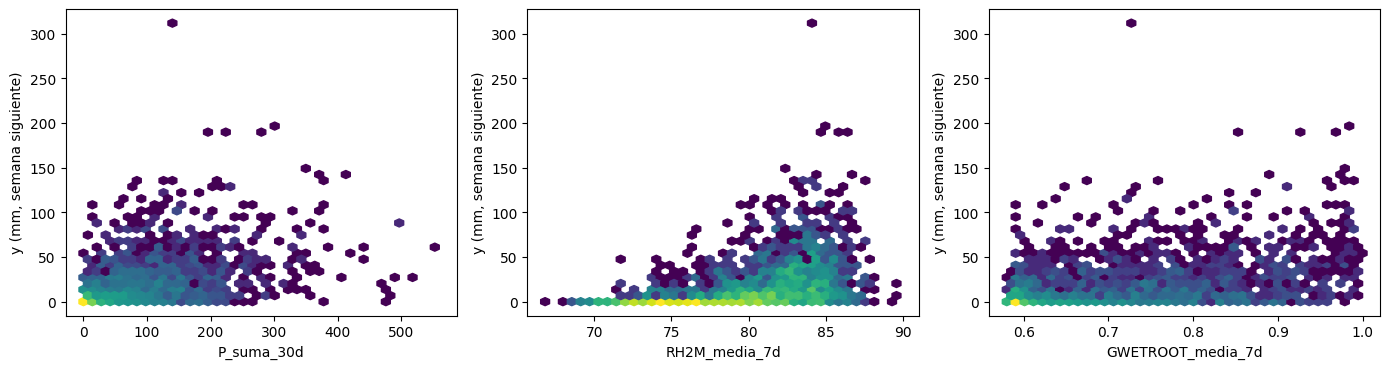

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
for a, v in zip(axs, ["P_suma_30d", "RH2M_media_7d", "GWETROOT_media_7d"]):
    if v in tab1:
        a.hexbin(tab1[v], tab1["y"], gridsize=40, bins="log", mincnt=1); a.set_xlabel(v); a.set_ylabel("y (mm, semana siguiente)")
plt.tight_layout(); plt.show()

**Información mutua** (capta relaciones no lineales que la correlación no ve).

In [14]:
from sklearn.feature_selection import mutual_info_regression
X_mi = tab1[pred_cols].fillna(tab1[pred_cols].median())
mi = mutual_info_regression(X_mi, tab1["y"], random_state=cfg.SEED)
pd.Series(mi, index=pred_cols).sort_values(ascending=False).round(4).head(15)

,0
dias_secos_consecutivos,0.3207
P_suma_7d,0.3091
WS2M_media_7d,0.2969
sin_doy,0.2926
P_suma_30d,0.2842
WS2M_media_30d,0.2625
sin3_doy,0.2294
cos_doy,0.2253
RH2M_media_7d,0.2109
P_suma_365d,0.1969


### Categóricas vs numérica: pruebas no paramétricas con tamaño de efecto

Se usa Kruskal-Wallis porque la lluvia no es normal. El tamaño de efecto es $\varepsilon^2 = H/(n-1)$. Como se hacen varias pruebas, los valores p se corrigen con Holm.

In [15]:
from src.series import holm
pruebas = []
t = tab1.assign(mes=tab1.fecha.dt.month, decada=(tab1.fecha.dt.year // 10) * 10)
if "ONI" in t:
    t["fase_enso"] = pd.cut(t["ONI"], [-np.inf, -0.5, 0.5, np.inf], labels=["La Niña", "Neutral", "El Niño"])
for factor in [c for c in ["mes", "decada", "punto", "fase_enso"] if c in t]:
    grupos = [g["y"].values for _, g in t.groupby(factor, observed=True)]
    if len(grupos) < 2:
        print(f"{factor}: un solo grupo, se omite"); continue
    H, p = stats.kruskal(*grupos)
    pruebas.append((factor, H, p, H / (len(t) - 1)))
res = pd.DataFrame(pruebas, columns=["factor", "H", "p", "epsilon2"])
res["p_Holm"] = holm(res["p"])
res.round(5)

punto: un solo grupo, se omite


,factor,H,p,epsilon2,p_Holm
0,mes,"1,207",0,0.5789,0
1,decada,37.92,0,0.01819,0


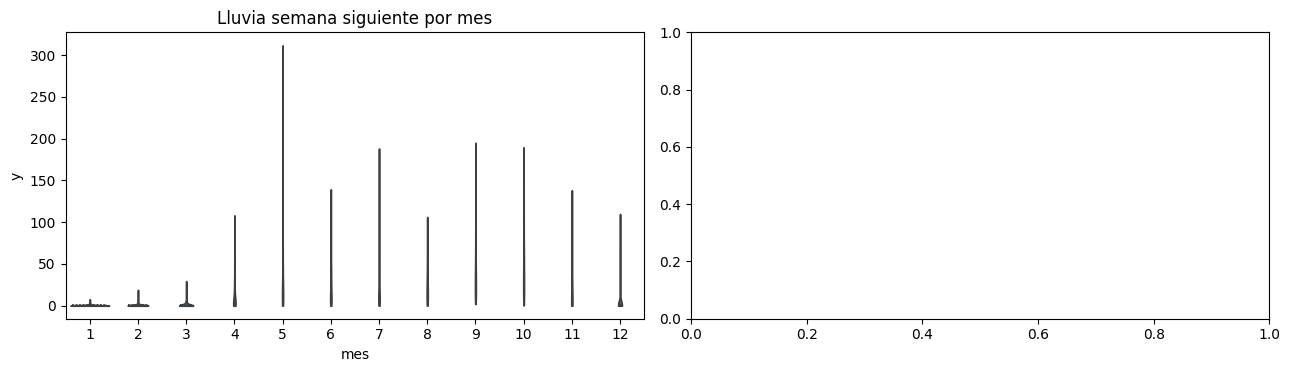

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(13, 3.8))
sns.violinplot(data=t, x="mes", y="y", ax=axs[0], cut=0, inner="quartile"); axs[0].set_title("Lluvia semana siguiente por mes")
if "fase_enso" in t:
    sns.boxplot(data=t, x="fase_enso", y="y", ax=axs[1], showfliers=False); axs[1].set_title("Por fase ENSO")
plt.tight_layout(); plt.show()

### Categóricas vs categóricas: $\chi^2$ y V de Cramér

In [17]:
def cramer_v(tabla):
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    n = tabla.values.sum()
    return chi2, p, np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

t["semana_lluviosa"] = np.where(t["y"] >= 10, "≥10 mm", "<10 mm")
for factor in [c for c in ["mes", "fase_enso"] if c in t]:
    ct = pd.crosstab(t[factor], t["semana_lluviosa"])
    if min(ct.shape) < 2:
        print(f"{factor}: una sola categoría, se omite"); continue
    chi2, p, v = cramer_v(ct)
    print(f"{factor}: chi2 = {chi2:.1f}, p = {p:.2e}, V de Cramér = {v:.3f}")
pd.crosstab(t["mes"], t["semana_lluviosa"], normalize="index").round(2)

mes: chi2 = 859.1, p = 3.87e-177, V de Cramér = 0.642


semana_lluviosa,<10 mm,≥10 mm
mes,,
1,1,0
2,0.98,0.02
3,0.97,0.03
4,0.7,0.3
5,0.32,0.68
6,0.4,0.6
7,0.46,0.54
8,0.25,0.75
9,0.13,0.87


### Multicolinealidad (VIF)

In [18]:
from src.series import vif as calcular_vif
Xv = tab1[pred_cols].dropna()
Xv = Xv.sample(min(20000, len(Xv)), random_state=cfg.SEED)
Xv = Xv.loc[:, Xv.std() > 0]
Xv = (Xv - Xv.mean()) / Xv.std()
vif = calcular_vif(Xv)
vif.sort_values(ascending=False).round(1)

,0
GWETROOT_media_30d,82.1
GWETROOT_media_7d,78.3
GWETTOP_media_30d,62.4
GWETTOP_media_7d,49
T2M_media_30d,34
T2M_MAX_media_30d,33.4
RH2M_media_30d,23.6
P_suma_90d,23.5
T2M_media_7d,22.7
T2M_MAX_media_7d,20.3


**Interpretación.** Las asociaciones más fuertes con la lluvia de la semana siguiente son la lluvia de los últimos 7 días (ρ = 0,69), los días secos consecutivos (ρ = −0,67) y el viento de los últimos 7 días (ρ = −0,66). El signo negativo del viento es físicamente coherente: los alisios intensos de la temporada seca, asociados al chorro de bajo nivel del Caribe, coinciden con ausencia de lluvia. La información mutua confirma el orden y destaca los términos del calendario, que capturan relaciones no lineales. El mes explica una gran parte de la variación (Kruskal-Wallis, ε² ≈ 0,58, efecto grande; V de Cramér ≈ 0,64 entre mes y semana lluviosa); la década, aunque significativa por el tamaño de muestra, tiene un efecto pequeño (ε² ≈ 0,02): con muestras grandes el tamaño de efecto, y no el valor p, indica relevancia. **Multicolinealidad:** las medias de 7 y 30 días de una misma variable son redundantes entre sí; los VIF más altos son los de la humedad del suelo (hasta 82), la temperatura (34) y la humedad relativa (24). Se conservan con regularización L2 del SVR, y sus coeficientes no se interpretan por separado.

## 2.4 Análisis multivariado

Componentes para 80 % y 95 % de varianza: 6 12
Varianza explicada: PC1 = 43.6%, PC2 = 17.3%


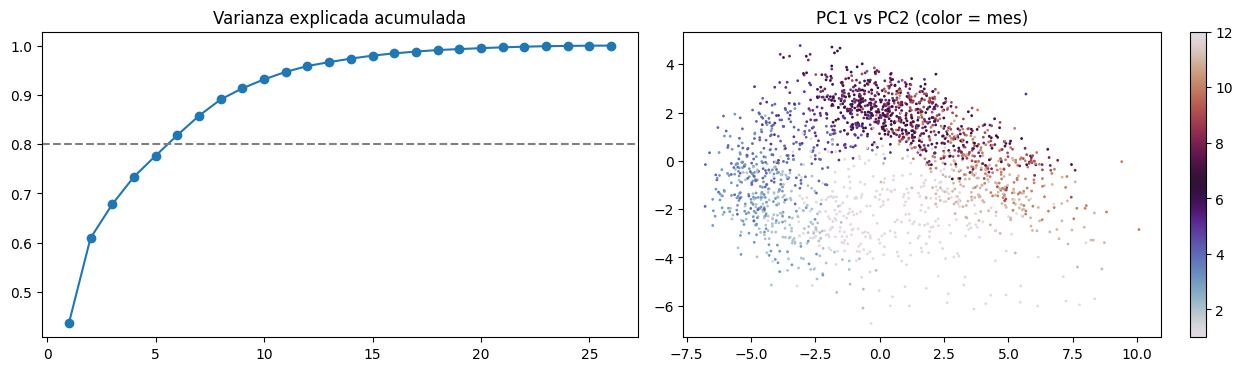

,PC1,PC2,PC3
P_suma_7d,0.18,0.07,-0
P_suma_30d,0.25,0.05,0.11
P_suma_90d,0.26,-0.1,0.23
P_suma_180d,0.17,-0.29,0.3
P_suma_365d,0.1,-0.13,0.42
dias_secos_consecutivos,-0.19,-0.18,0.1
T2M_media_7d,0.02,0.42,0.15
T2M_media_30d,0.07,0.43,0.07
T2M_MAX_media_7d,-0.16,0.3,0.22
T2M_MAX_media_30d,-0.15,0.36,0.1


In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Xm = tab1[pred_cols].dropna()
Xs = StandardScaler().fit_transform(Xm)
pca = PCA(random_state=cfg.SEED).fit(Xs)
acum = np.cumsum(pca.explained_variance_ratio_)
print("Componentes para 80 % y 95 % de varianza:", np.argmax(acum >= .8) + 1, np.argmax(acum >= .95) + 1)
print(f"Varianza explicada: PC1 = {pca.explained_variance_ratio_[0]:.1%}, PC2 = {pca.explained_variance_ratio_[1]:.1%}")
fig, axs = plt.subplots(1, 2, figsize=(13, 3.8))
axs[0].plot(range(1, len(acum) + 1), acum, marker="o"); axs[0].axhline(.8, ls="--", c="grey"); axs[0].set_title("Varianza explicada acumulada")
Z = pca.transform(Xs)[:, :2]
sc = axs[1].scatter(Z[:, 0], Z[:, 1], c=tab1.loc[Xm.index, "fecha"].dt.month, s=1, cmap="twilight")
axs[1].set_title("PC1 vs PC2 (color = mes)"); plt.colorbar(sc, ax=axs[1])
plt.tight_layout(); plt.show()
pd.DataFrame(pca.components_[:3].T, index=Xm.columns, columns=["PC1", "PC2", "PC3"]).round(2)

### Outliers multivariados

In [20]:
from sklearn.ensemble import IsolationForest
from sklearn.covariance import MinCovDet
iso = IsolationForest(contamination="auto", random_state=cfg.SEED).fit(Xs)
atipico_iso = iso.predict(Xs) == -1
mcd = MinCovDet(random_state=cfg.SEED).fit(Xs[np.random.default_rng(cfg.SEED).choice(len(Xs), min(5000, len(Xs)), replace=False)])
d2 = mcd.mahalanobis(Xs)
atipico_mah = d2 > stats.chi2.ppf(0.999, Xs.shape[1])
print(f"Isolation Forest: {atipico_iso.mean():.2%}  |  Mahalanobis robusta (p<0.001): {atipico_mah.mean():.2%}  |  ambos: {(atipico_iso & atipico_mah).mean():.2%}")
print(tab1.loc[Xm.index[atipico_iso & atipico_mah], "fecha"].dt.year.value_counts().head(10))

Isolation Forest: 15.01%  |  Mahalanobis robusta (p<0.001): 52.02%  |  ambos: 9.97%
fecha
2017    36
2011    25
2010    15
2020    14
1985    13
2012    13
2018     9
2000     8
2014     8
1992     6
Name: count, dtype: int64


### Estructura de grupos (regímenes climáticos)

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
idx = np.random.default_rng(cfg.SEED).choice(len(Xs), min(8000, len(Xs)), replace=False)
Z5 = pca.transform(Xs)[:, :5]
for k in range(2, 7):
    km = KMeans(k, n_init=10, random_state=cfg.SEED).fit(Z5[idx])
    print(k, round(silhouette_score(Z5[idx], km.labels_), 3))

2 0.333
3 0.333
4 0.341
5 0.325
6 0.28


In [22]:
k = 2  # ajustar según la silueta
km = KMeans(k, n_init=10, random_state=cfg.SEED).fit(Z5)
g = tab1.loc[Xm.index].assign(grupo=km.labels_)
g.groupby("grupo").agg(y_media=("y", "mean"), n=("y", "size")).join(
    g.groupby("grupo")["fecha"].apply(lambda s: s.dt.month.mode().iloc[0]).rename("mes_modal"))

,y_media,n,mes_modal
grupo,,,
0,8.303,924,3
1,28.6,1002,10


**Interpretación.** El primer componente explica el 43,6 % de la varianza y agrupa humedad del suelo, humedad relativa y lluvia acumulada con signo opuesto al viento y la radiación: es un eje de régimen húmedo frente a seco. El segundo (17,3 %) combina temperatura y ciclo anual. Se necesitan 6 componentes para el 80 % de la varianza y 12 para el 95 %: la dimensionalidad efectiva es mucho menor que las 26 predictoras, coherente con el VIF. La distancia de Mahalanobis robusta marca como atípica más de la mitad de las semanas, señal de que la distribución conjunta está lejos de la normal; Isolation Forest (15 %) es más adecuado. Las semanas atípicas para ambos métodos se concentran en 2017, 2011 y 2010, años de La Niña con lluvias extremas: son eventos reales y se conservan. La silueta es parecida para 2 y 4 grupos (≈ 0,33–0,34); con dos grupos se separa un régimen húmedo (mes típico octubre, 28,6 mm en la semana siguiente) de uno seco (mes típico marzo, 8,3 mm).

## 2.5 Auditoría de fuga de datos

Cada predictora debe estar disponible en el momento de emitir el pronóstico. En este proyecto eso significa: todas las variables de POWER se usan rezagadas `cfg.LATENCIA_DIAS` días y resumidas con ventanas del pasado; los componentes cíclicos del calendario sí se conocen de antemano; el ONI (cuando está disponible) se rezaga 75 días por su fecha de publicación.

In [23]:
disponibilidad = pd.DataFrame({
    "predictora": pred_cols,
    "disponible en t": ["sí (calendario)" if c.startswith(("sin", "cos")) else
                        "sí (estática)" if c in ("lat", "lon", "elevacion_m") else
                        "sí (rezago 75 d)" if c == "ONI" else
                        f"sí (pasado, rezago {cfg.LATENCIA_DIAS} d)" for c in pred_cols],
})
disponibilidad

,predictora,disponible en t
0,P_suma_7d,"sí (pasado, rezago 3 d)"
1,P_suma_30d,"sí (pasado, rezago 3 d)"
2,P_suma_90d,"sí (pasado, rezago 3 d)"
3,P_suma_180d,"sí (pasado, rezago 3 d)"
4,P_suma_365d,"sí (pasado, rezago 3 d)"
5,dias_secos_consecutivos,"sí (pasado, rezago 3 d)"
6,T2M_media_7d,"sí (pasado, rezago 3 d)"
7,T2M_media_30d,"sí (pasado, rezago 3 d)"
8,T2M_MAX_media_7d,"sí (pasado, rezago 3 d)"
9,T2M_MAX_media_30d,"sí (pasado, rezago 3 d)"


**Desempeño univariado.** Cada predictora sola en un árbol poco profundo con validación cronológica. Un R² cercano a 1 sería señal de fuga.

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
r2_uni = {}
splits = list(md.cv_temporal(tab1.fecha, n_splits=3, gap_dias=7 + cfg.LATENCIA_DIAS))
for c in pred_cols:
    vals = []
    for tr, va in splits:
        a, b = tab1.iloc[tr], tab1.iloc[va]
        ok_a, ok_b = a[c].notna(), b[c].notna()
        m = DecisionTreeRegressor(max_depth=3, random_state=cfg.SEED).fit(a.loc[ok_a, [c]], a.loc[ok_a, "y"])
        vals.append(r2_score(b.loc[ok_b, "y"], m.predict(b.loc[ok_b, [c]])))
    r2_uni[c] = np.mean(vals)
pd.Series(r2_uni).sort_values(ascending=False).round(3)

,0
dias_secos_consecutivos,0.202
P_suma_7d,0.197
P_suma_30d,0.177
WS2M_media_30d,0.173
WS2M_media_7d,0.167
RH2M_media_7d,0.165
GWETTOP_media_7d,0.135
sin_doy,0.132
RH2M_media_30d,0.121
GWETROOT_media_7d,0.1


**Contraejemplo didáctico:** la humedad relativa del *mismo* periodo del objetivo explica mucho más, pero no se conoce al momento de pronosticar. Por eso no se usa.

In [25]:
g = train_df[train_df.punto == REF].set_index("fecha").sort_index()
y1 = md.objetivo_semana_h(g[OBJ], 1)
rh_futura = g["RH2M"][::-1].rolling(7).mean()[::-1].shift(-1)   # HR de la misma semana objetivo: FUGA
rh_pasada = g["RH2M"].rolling(7).mean().shift(cfg.LATENCIA_DIAS)
print("Spearman con HR de la semana objetivo (fuga):", round(y1.corr(rh_futura, method="spearman"), 3))
print("Spearman con HR pasada (válida):             ", round(y1.corr(rh_pasada, method="spearman"), 3))

Spearman con HR de la semana objetivo (fuga): 0.798
Spearman con HR pasada (válida):              0.603


In [26]:
te_ = df[(df.punto == cfg.PUNTO_OBJETIVO) & (df.fecha >= cfg.INICIO_TEST)]
print("Fechas compartidas entre entrenamiento y prueba:", len(set(train_df.fecha) & set(te_.fecha)))
if N_SITIOS == 1:
    print("Un solo sitio: la separación entre entrenamiento y prueba es cronológica (1981–2020 frente a 2021–2025).")
else:
    print("Sitios presentes en ambos:", sorted(set(train_df.punto) & set(te_.punto)))
    print("La celda regional más cercana a la finca se excluyó al construir el dataset.")

Fechas compartidas entre entrenamiento y prueba: 0
Un solo sitio: la separación entre entrenamiento y prueba es cronológica (1981–2020 frente a 2021–2025).


**Interpretación.** Ninguna predictora sola se acerca a un ajuste perfecto (R² univariado máximo ≈ 0,20, días secos consecutivos), así que no hay variables derivadas del objetivo. Todas las variables de POWER se usan con 3 días de rezago (latencia de publicación) y los términos del calendario se conocen de antemano. Como contraejemplo, la humedad relativa de la misma semana que se pronostica tiene una correlación de 0,80 con la lluvia, frente a 0,60 de la humedad pasada: usarla inflaría el desempeño con información no disponible al pronosticar. Se descarta toda variable del mismo periodo del objetivo; no hay fechas compartidas entre entrenamiento y prueba y se purgan las filas cuya semana objetivo cae en 2021.

## 2.6 Componente temporal

In [27]:
for p_, g in train_df.groupby("punto"):
    d = g.fecha.sort_values().diff().dt.days
    print(f"{p_}: frecuencia modal = {d.mode().iloc[0]} día(s), saltos > 1 día = {(d > 1).sum()}, marcas duplicadas = {g.fecha.duplicated().sum()}")
print("Zona horaria: los días corresponden a la hora estándar local (LST) solicitada a la API; no hay horas que ajustar.")

FINCA_SABANAGRANDE: frecuencia modal = 1.0 día(s), saltos > 1 día = 0, marcas duplicadas = 0
Zona horaria: los días corresponden a la hora estándar local (LST) solicitada a la API; no hay horas que ajustar.


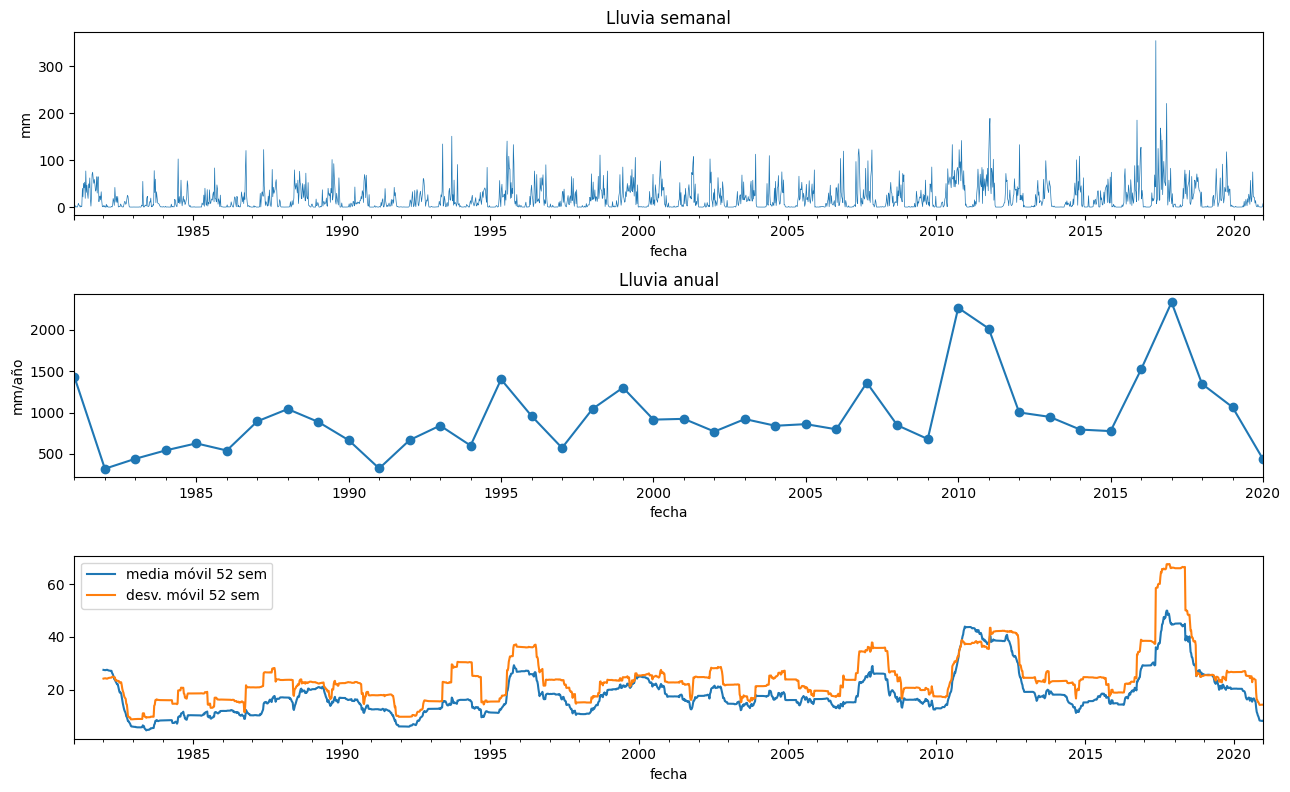

In [28]:
fig, axs = plt.subplots(3, 1, figsize=(13, 8))
obj_sem[OBJ].plot(ax=axs[0], lw=.5); axs[0].set_title("Lluvia semanal"); axs[0].set_ylabel("mm")
obj_sem[OBJ].resample("YE").sum().plot(ax=axs[1], marker="o"); axs[1].set_title("Lluvia anual"); axs[1].set_ylabel("mm/año")
obj_sem[OBJ].rolling(52).mean().plot(ax=axs[2], label="media móvil 52 sem")
obj_sem[OBJ].rolling(52).std().plot(ax=axs[2], label="desv. móvil 52 sem"); axs[2].legend()
plt.tight_layout(); plt.show()

### Descomposición en tendencia, estacionalidad y residuo (periodo 52 semanas)

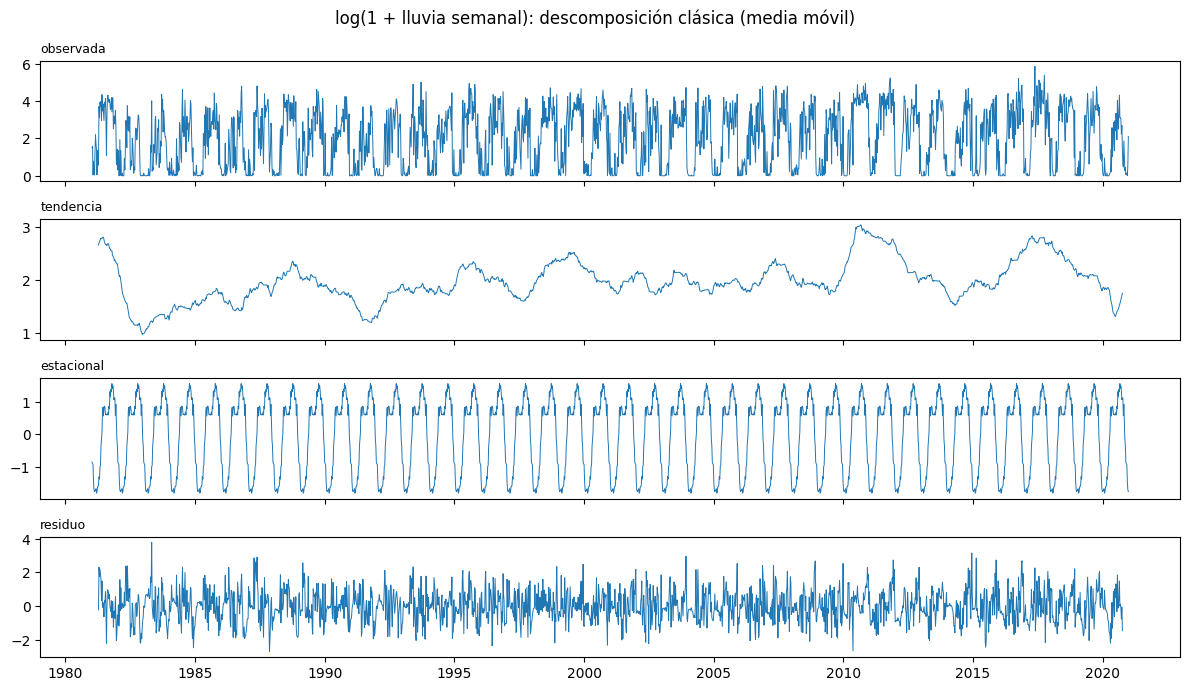

Fuerza de la estacionalidad: 0.60   Fuerza de la tendencia: 0.17


In [29]:
from src import series
serie = obj_sem[OBJ].asfreq("W-SUN").fillna(0)
desc, metodo = series.descomponer(np.log1p(serie), periodo=52)
fig, axs = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for a, c in zip(axs, desc.columns):
    a.plot(desc.index, desc[c], lw=.7); a.set_title(c, loc="left", fontsize=9)
plt.suptitle(f"log(1 + lluvia semanal): descomposición {metodo}"); plt.tight_layout(); plt.show()
fe, ft = series.fuerza(desc)
print(f"Fuerza de la estacionalidad: {fe:.2f}   Fuerza de la tendencia: {ft:.2f}")

### Estacionariedad: ADF y KPSS

ADF tiene como hipótesis nula una raíz unitaria; KPSS tiene como nula la estacionariedad. Se interpretan juntas.

In [30]:
filas = []
for nombre, s in {"log(1 + lluvia semanal)": np.log1p(serie), "radiación semanal": obj_sem["ALLSKY_SFC_SW_DWN"].asfreq("W-SUN").interpolate().dropna()}.items():
    ea, pa = series.adf(s); ek, pk = series.kpss(s)
    filas.append({"serie": nombre, "ADF": ea, "p ADF": pa, "KPSS": ek, "p KPSS": pk})
pd.DataFrame(filas).round(4)

,serie,ADF,p ADF,KPSS,p KPSS
0,log(1 + lluvia semanal),-12.24,0.01,0.4048,0.1
1,radiación semanal,-13.54,0.01,0.2886,0.1


### Dependencia temporal: ACF, PACF y correlación cruzada

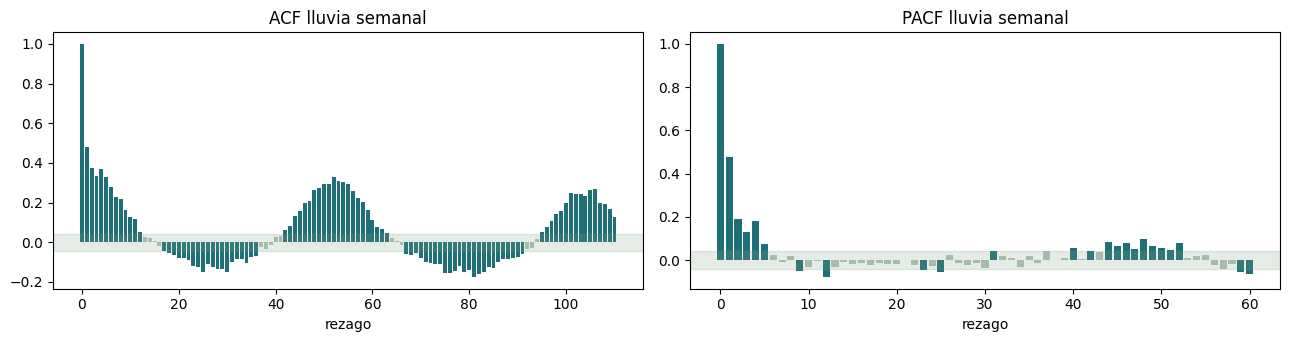

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(13, 3.5))
series.graficar_acf(axs[0], series.acf(serie.values, 110), len(serie), "ACF lluvia semanal")
series.graficar_acf(axs[1], series.pacf(serie.values, 60), len(serie), "PACF lluvia semanal")
plt.tight_layout(); plt.show()

In [32]:
mensual = train_df[train_df.punto == REF].set_index("fecha")[[OBJ] + (["ONI"] if "ONI" in train_df else [])].resample("MS").agg({OBJ: "sum", **({"ONI": "mean"} if "ONI" in train_df else {})})
mensual["anomalia"] = mensual[OBJ] - mensual.groupby(mensual.index.month)[OBJ].transform("mean")
if "ONI" in mensual:
    cc = {k: mensual["anomalia"].corr(mensual["ONI"].shift(k), method="spearman") for k in range(0, 13)}
    ax = pd.Series(cc).plot.bar(figsize=(8, 3), title="Anomalía de lluvia mensual vs ONI rezagado k meses (Spearman)")
    ax.set_xlabel("rezago (meses)"); plt.show()
else:
    print("El dataset de este entregable no incluye el ONI: la correlación cruzada con ENSO se calcula con el dataset del notebook 00.")

El dataset de este entregable no incluye el ONI: la correlación cruzada con ENSO se calcula con el dataset del notebook 00.


In [33]:
# Resumen cuantitativo del componente temporal (respalda la interpretación)
a_ = series.acf(serie.values, 110); banda = 1.96 / np.sqrt(len(serie))
consec = int(np.argmax(np.abs(a_[1:]) < banda)) if (np.abs(a_[1:]) < banda).any() else 110
anual_ = obj_sem[OBJ].resample("YE").sum(); anual_ = anual_[anual_.index.year < pd.Timestamp(cfg.INICIO_TEST).year]
anual_.index = anual_.index.year
t_anual = train_df.set_index("fecha")["T2M"].resample("YE").mean(); t_anual.index = t_anual.index.year
tp, tt = stats.linregress(anual_.index, anual_.values), stats.linregress(t_anual.index, t_anual.values)
pd.Series({
    "ACF rezago 1": round(a_[1], 3), "ACF rezago 52": round(a_[52], 3),
    "semanas seguidas con ACF significativa": consec,
    "coef. de variación de la lluvia anual": round(anual_.std() / anual_.mean(), 3),
    "año más seco (mm)": f"{anual_.idxmin()} ({anual_.min():.0f})", "año más lluvioso (mm)": f"{anual_.idxmax()} ({anual_.max():.0f})",
    "tendencia lluvia (mm/década, p)": f"{tp.slope * 10:.0f} (p = {tp.pvalue:.3f})",
    "tendencia temperatura (°C/década, p)": f"{tt.slope * 10:.2f} (p = {tt.pvalue:.3f})",
}).to_frame("valor")

,valor
ACF rezago 1,0.478
ACF rezago 52,0.331
semanas seguidas con ACF significativa,12
coef. de variación de la lluvia anual,0.483
año más seco (mm),1982 (320)
año más lluvioso (mm),2017 (2333)
"tendencia lluvia (mm/década, p)",168 (p = 0.007)
"tendencia temperatura (°C/década, p)",0.11 (p = 0.002)


### Cambios de régimen: prueba de Pettitt sobre la lluvia anual

In [34]:
def pettitt(x):
    x = np.asarray(x); n = len(x)
    r = stats.rankdata(x)
    U = np.array([2 * r[:k].sum() - k * (n + 1) for k in range(1, n)])
    K = np.abs(U).max(); k = np.abs(U).argmax()
    return k + 1, K, min(1, 2 * np.exp(-6 * K**2 / (n**3 + n**2)))

anual = obj_sem[OBJ].resample("YE").sum()
anual = anual[anual.index.year < pd.Timestamp(cfg.INICIO_TEST).year]
k, K, p = pettitt(anual.values)
print(f"Punto de cambio más probable: {anual.index[k].year}  (K = {K:.0f}, p = {p:.3f})")

Punto de cambio más probable: 1995  (K = 210, p = 0.035)


### Deriva: comparación de distribuciones por década

In [35]:
dec = semanal[semanal.punto == REF].assign(decada=lambda d: (d.fecha.dt.year // 10) * 10)
base = dec[dec.decada == dec.decada.min()]
filas = []
for v in [OBJ, "T2M", "RH2M", "ALLSKY_SFC_SW_DWN", "GWETROOT"]:
    for d_, g in dec.groupby("decada"):
        if d_ == dec.decada.min():
            continue
        ks = stats.ks_2samp(base[v].dropna(), g[v].dropna())
        filas.append((v, d_, g[v].mean() - base[v].mean(), stats.wasserstein_distance(base[v].dropna(), g[v].dropna()), ks.pvalue))
deriva = pd.DataFrame(filas, columns=["variable", "década", "Δ media vs 1ª década", "Wasserstein", "p KS"])
deriva["p_Holm"] = holm(deriva["p KS"])
deriva.round(3)

,variable,década,Δ media vs 1ª década,Wasserstein,p KS,p_Holm
0,PRECTOTCORR,1990,1.739,1.836,0.216,0.865
1,PRECTOTCORR,2000,2.737,2.739,0.12,0.812
2,PRECTOTCORR,2010,12.61,12.61,0,0
3,PRECTOTCORR,2020,-5.952,5.952,0.115,0.812
4,T2M,1990,0.074,0.076,0.344,0.865
5,T2M,2000,0.242,0.242,0,0
6,T2M,2010,0.258,0.259,0,0
7,T2M,2020,0.829,0.829,0,0
8,RH2M,1990,0.237,0.432,0.239,0.865
9,RH2M,2000,0.274,0.501,0.086,0.778


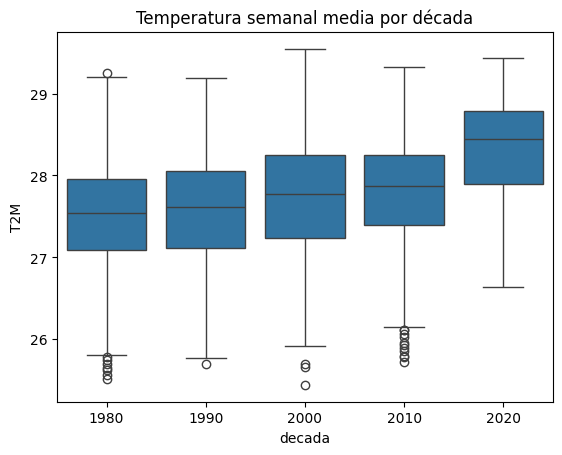

In [36]:
sns.boxplot(data=dec, x="decada", y="T2M"); plt.title("Temperatura semanal media por década"); plt.show()

### Heterogeneidad entre puntos (panel)

In [37]:
if N_SITIOS > 1:
    sns.boxplot(data=semanal, x="punto", y=OBJ, showfliers=False); plt.xticks(rotation=30); plt.title("Lluvia semanal por punto"); plt.show()
else:
    print("Un solo sitio: la heterogeneidad entre sitios se analiza con la grilla regional.")

Un solo sitio: la heterogeneidad entre sitios se analiza con la grilla regional.


**Interpretación.** La estacionalidad domina la serie (fuerza estacional ≈ 0,60 frente a ≈ 0,17 de la tendencia). La lluvia es estacionaria alrededor de su ciclo: KPSS no rechaza la estacionariedad al 5 % y ADF rechaza con amplitud la raíz unitaria; lo mismo ocurre con la radiación solar. La ACF muestra memoria de corto plazo (ρ₁ ≈ 0,48, significativa durante unas 12 semanas seguidas) y el ciclo anual (ρ₅₂ ≈ 0,33); la PACF cae después de los primeros rezagos. La lluvia anual varía mucho entre años (coeficiente de variación ≈ 0,48): mínimos en años de El Niño (1982, con unos 320 mm, y 1991) y máximos en años de La Niña (2010–2011, 2017). Hay una tendencia positiva de la lluvia (unos 170 mm por década, p ≈ 0,007, impulsada por 2010–2018) y la prueba de Pettitt ubica un cambio en 1995 (p ≈ 0,035); la temperatura sube unos 0,11 °C por década. En la comparación por décadas, la lluvia de los años 2010 es significativamente mayor (+12,6 mm por semana) y la temperatura sube desde los 2000; la década de 2020 en entrenamiento solo contiene el año 2020. **Consecuencias:** partición cronológica con purga; validación de ventana creciente con separación de 7h + 3 días; predictoras de hasta 365 días; armónicos del ciclo anual; y vigilancia de la deriva, que puede degradar el modelo en el periodo de prueba. La serie de este entregable no incluye el ONI; la correlación cruzada con ENSO se reportará con el dataset del notebook 00.

## 2.7 Componente espacial

In [38]:
if N_SITIOS < 3:
    print("No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).")
else:
    coords = train_df.groupby("punto")[["lat", "lon", "elevacion_m"]].first()
    print("CRS: EPSG:4326 (grados decimales, datum WGS84)")
    print("Latitudes válidas:", coords.lat.between(-90, 90).all(), "| Longitudes válidas:", coords.lon.between(-180, 180).all())
    print("¿Posible inversión lat/lon? (Caribe colombiano: lat 8–12, lon -77 a -72):",
          (~coords.lat.between(7.5, 12) | ~coords.lon.between(-77.5, -72)).any())
    D = esp.matriz_distancias(coords.lat, coords.lon)
    display(pd.DataFrame(D, index=coords.index, columns=coords.index).round(0))
    print("Distancia al vecino más cercano (km):", np.sort(np.where(D > 0, D, np.inf), axis=1)[:, 0].round(0))

No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).


In [39]:
if N_SITIOS < 3:
    print("No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).")
else:
    clim = train_df.groupby("punto").agg(lat=("lat", "first"), lon=("lon", "first"),
                                         lluvia_anual=(OBJ, lambda s: s.mean() * 365.25), t_media=("T2M", "mean"))
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
    for a, v in zip(axs, ["lluvia_anual", "t_media"]):
        sc = a.scatter(clim.lon, clim.lat, c=clim[v], s=160, cmap="viridis_r" if v == "lluvia_anual" else "magma", edgecolor="k")
        a.scatter([cfg.LON_FINCA], [cfg.LAT_FINCA], marker="*", s=400, c="red", edgecolor="k", label="finca (prueba)")
        a.legend(loc="lower left", fontsize=8)
        a.set_title(v); a.set_xlabel("lon"); a.set_ylabel("lat"); plt.colorbar(sc, ax=a)
    plt.tight_layout(); plt.show()
    # Para mapa base: instalar contextily y usar geopandas (requiere internet).

No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).


### Autocorrelación espacial

Pesos por inverso de la distancia haversine, estandarizados por fila: en una grilla regular cada sitio pesa más a sus vecinos inmediatos sin fijar un umbral arbitrario. Con la grilla regional (unos 40 sitios) la prueba de permutación del I de Moran tiene potencia razonable.

In [40]:
if N_SITIOS < 3:
    print("No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).")
else:
    W = esp.pesos_inverso_distancia(clim.lat, clim.lon)
    print("Lluvia anual:", esp.moran_i(clim.lluvia_anual, W))
    print("Temperatura media:", esp.moran_i(clim.t_media, W))

No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).


In [41]:
if N_SITIOS < 3:
    print("No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).")
else:
    # Semivariograma empírico de la lluvia anual (distancia haversine)
    D_ = esp.matriz_distancias(clim.lat, clim.lon)
    iu = np.triu_indices(len(clim), 1)
    g_ = 0.5 * (clim.lluvia_anual.values[:, None] - clim.lluvia_anual.values[None, :]) ** 2
    bins = np.linspace(0, D_[iu].max(), 10)
    k_ = np.digitize(D_[iu], bins)
    vg = pd.DataFrame({"d": D_[iu], "g": g_[iu], "k": k_}).groupby("k").agg(d=("d", "mean"), gamma=("g", "mean"), n=("g", "size"))
    plt.plot(vg.d, vg.gamma, "o-"); plt.xlabel("distancia (km)"); plt.ylabel("semivarianza (mm²)"); plt.title("Semivariograma de la lluvia anual"); plt.show()
    vg.round(1)

No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).


**Interpretación.** No aplica con un solo sitio. Estas secciones (I de Moran, semivariograma, correlación en función de la distancia) ya están implementadas y se ejecutarán con la grilla regional del notebook 00 en el segundo entregable.

## 2.8 Componente espacio-temporal

In [42]:
if N_SITIOS < 3:
    print("No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).")
else:
    mes_punto = train_df.assign(mes=train_df.fecha.dt.month).groupby(["punto", "mes"])[OBJ].mean().mul(30.4).unstack()
    fig, axs = plt.subplots(2, 6, figsize=(16, 5.5), sharex=True, sharey=True)
    vmax = mes_punto.values.max()
    for m_, a in zip(range(1, 13), axs.ravel()):
        a.scatter(coords.loc[mes_punto.index, "lon"], coords.loc[mes_punto.index, "lat"], c=mes_punto[m_], s=120, cmap="Blues", vmin=0, vmax=vmax, edgecolor="k")
        a.set_title(f"Mes {m_}", fontsize=9)
    plt.suptitle("Lluvia media mensual por punto (mm/mes)"); plt.tight_layout(); plt.show()

No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).


In [43]:
if N_SITIOS < 3:
    print("No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).")
else:
    moran_mes = {m_: esp.moran_i(mes_punto[m_].values, W, n_perm=499)["I"] for m_ in range(1, 13)}
    pd.Series(moran_mes).plot.bar(figsize=(8, 3), title="I de Moran de la lluvia media por mes"); plt.axhline(-1 / (len(W) - 1), c="grey", ls="--"); plt.show()

No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).


In [44]:
if N_SITIOS < 3:
    print("No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).")
else:
    # Correlación entre sitios según la distancia, por temporada
    ancho = semanal.pivot(index="fecha", columns="punto", values=OBJ)
    temporada = np.where(ancho.index.month.isin([12, 1, 2, 3]), "seca (dic-mar)", "lluviosa (abr-nov)")
    Dp = esp.matriz_distancias(coords.loc[ancho.columns, "lat"], coords.loc[ancho.columns, "lon"])
    iu = np.triu_indices(len(ancho.columns), 1)
    for t_ in np.unique(temporada):
        c_ = ancho[temporada == t_].corr(method="spearman").values[iu]
        plt.scatter(Dp[iu], c_, s=6, alpha=.5, label=t_)
    plt.xlabel("distancia entre sitios (km)"); plt.ylabel("correlación de Spearman (lluvia semanal)"); plt.legend(); plt.title("Decaimiento de la correlación con la distancia"); plt.show()

No aplica con un solo sitio: el análisis espacial requiere varios sitios (diseño regional).


**Interpretación.** No aplica con un solo sitio. Estas secciones (I de Moran, semivariograma, correlación en función de la distancia) ya están implementadas y se ejecutarán con la grilla regional del notebook 00 en el segundo entregable.

## 2.9 Preprocesamiento: decisiones trazables al EDA

Todo se implementa dentro de un `Pipeline` ajustado solo con entrenamiento (ver `src/modelado.py`).

| Decisión | Hallazgo del EDA que la motiva |
|---|---|
| Imputación por mediana dentro del Pipeline | Faltantes de radiación en 1981–1983, mecanismo MAR respecto a la fecha (notebook 01) |
| Escalado estándar | Magnitudes muy distintas entre variables (2.2) |
| Conservar outliers | Extremos reales asociados a La Niña (2.2, 2.4) |
| Sumas y medias móviles pasadas de 7 a 365 días, con 3 días de rezago | Memoria de la ACF y ciclo anual (2.6); latencia de publicación (2.5) |
| Tres armónicos del día del año | Ciclo bimodal que un solo seno y coseno no representa (2.1, 2.6) |
| Solo variables del Excel (sin ET0 ni otras derivadas) | El EDA y el modelo de regresión se limitan a los datos observados; la ET0 se usa solo en el análisis final |
| Regularización L2 del SVR | Colinealidad entre humedad relativa, humedad del suelo, radiación y viento (2.3, 2.4) |
| Transformación del objetivo como hiperparámetro | Asimetría de la lluvia (2.1) |
| Partición cronológica con purga y separación de 7h + 3 días | Dependencia temporal y estacionalidad (2.6) |